In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [13]:
import os

print(os.getcwd())

C:\Users\Atharva Shendkar\OneDrive\Desktop\Unsupervised Learning Projects


In [14]:
import os

print(os.listdir())

['.ipynb_checkpoints', 'K-Means & Hierarchical']


In [16]:

import os

print(os.getcwd())
print(os.listdir())

C:\Users\Atharva Shendkar\OneDrive\Desktop\Unsupervised Learning Projects
['.ipynb_checkpoints', 'K-Means & Hierarchical']


In [18]:
import os

os.chdir(r"C:\Users\Atharva Shendkar\OneDrive\Desktop\Unsupervised Learning Projects\K-Means & Hierarchical")

import pandas as pd
df = pd.read_csv("StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


# Understanding Data

In [21]:
df.head()


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


# Encoding 

In [23]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,0,1,1,1,1,72,72,74
1,0,2,4,1,0,69,90,88
2,0,1,3,1,1,90,95,93
3,1,0,0,0,1,47,57,44
4,1,2,4,1,1,76,78,75


In [25]:
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()

scaled_data = scaler.fit_transform(df)

scaled_df = pd.DataFrame(scaled_data, columns=df.columns)






# Exploratory Data Analysis

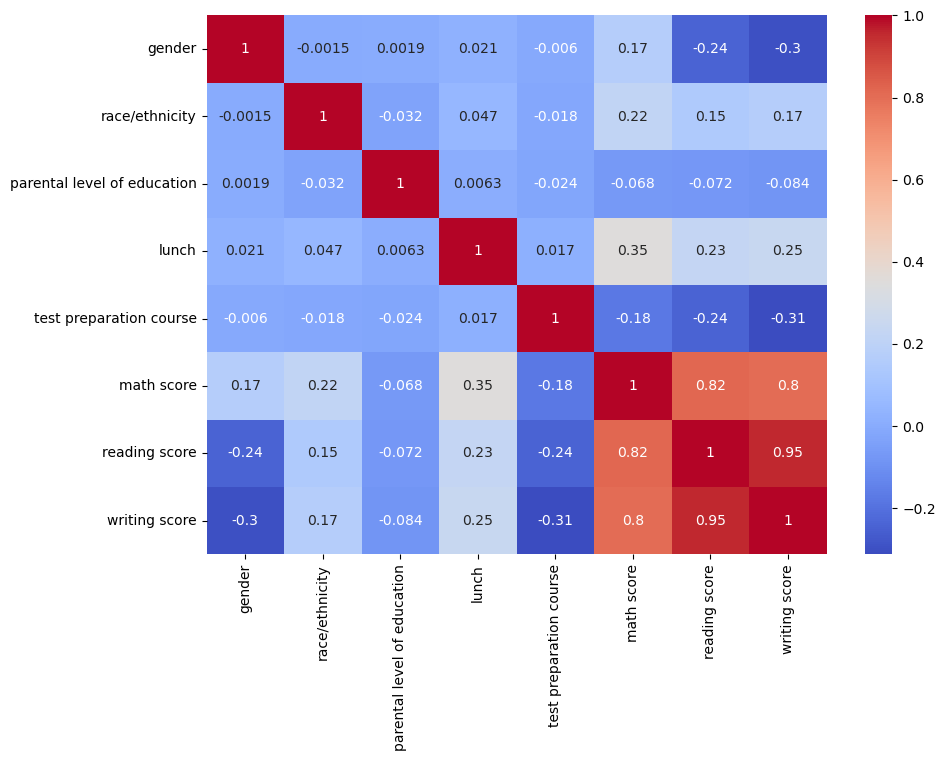

In [26]:
plt.figure(figsize=(10,7))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

plt.show()

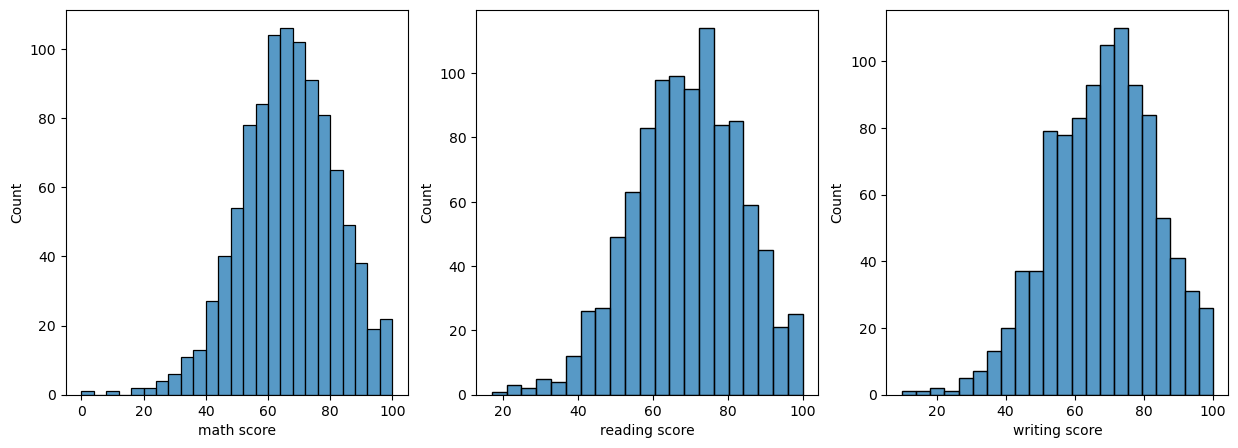

In [27]:
fig, ax = plt.subplots(1,3, figsize=(15,5))

sns.histplot(df["math score"], ax=ax[0])

sns.histplot(df["reading score"], ax=ax[1])

sns.histplot(df["writing score"], ax=ax[2])

plt.show()

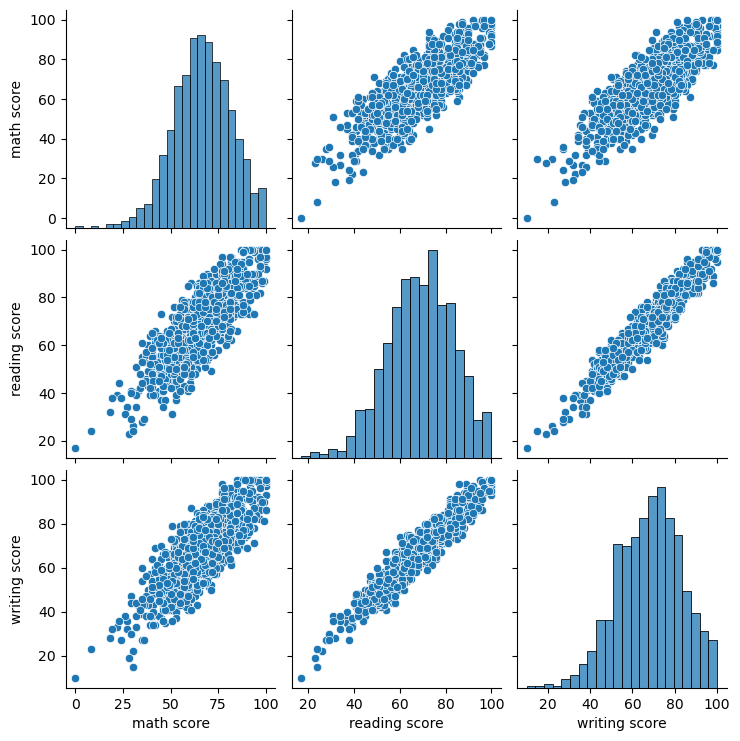

In [28]:
sns.pairplot(df[['math score',
                 'reading score',
                 'writing score']])

plt.show()

# Finding Optimal Number of Clusters

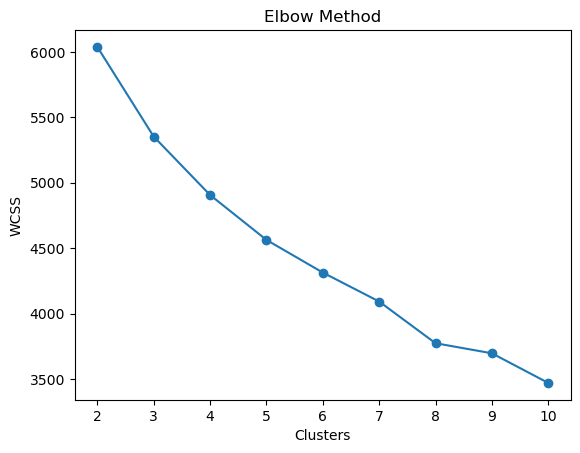

In [30]:
# Elbow Method

from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss = []

for i in range(2,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_df)
    wcss.append(kmeans.inertia_)

plt.plot(range(2,11), wcss, marker='o')

plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()

2 0.21074976301638212
3 0.1741060445115868
4 0.1634971307113737
5 0.1555681734321958
6 0.1619249450635211
7 0.1616151017091974
8 0.18613252919534382
9 0.1905884195363782
10 0.19421561208830143


<Axes: >

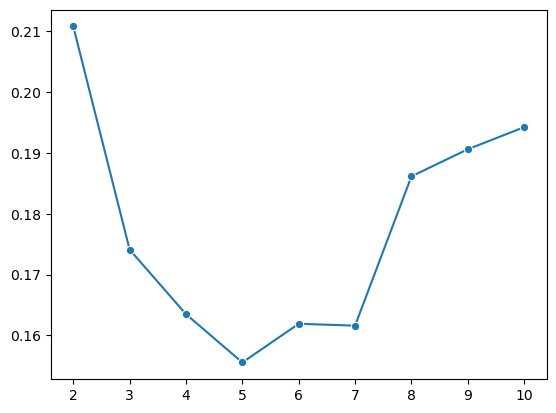

In [35]:
from sklearn.metrics import silhouette_score

scores = []
for i in range(2,11):

    model = KMeans(n_clusters=i, random_state=42)

    labels = model.fit_predict(scaled_df)

    score = silhouette_score(scaled_df, labels)

    print(i, score)
    scores.append(score)


sns.lineplot(x = range(2,11) , y = scores , marker = 'o')    

# Apply K-Means

In [37]:
kmeans = KMeans(n_clusters=3, random_state=42)

df['KMeans_Cluster'] = kmeans.fit_predict(scaled_df)

df["KMeans_Cluster"].value_counts()

KMeans_Cluster
1    362
0    354
2    284
Name: count, dtype: int64

In [39]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=3)

df["Agg_Cluster"] = agg.fit_predict(scaled_df)

df["Agg_Cluster"].value_counts()

Agg_Cluster
0    519
1    316
2    165
Name: count, dtype: int64

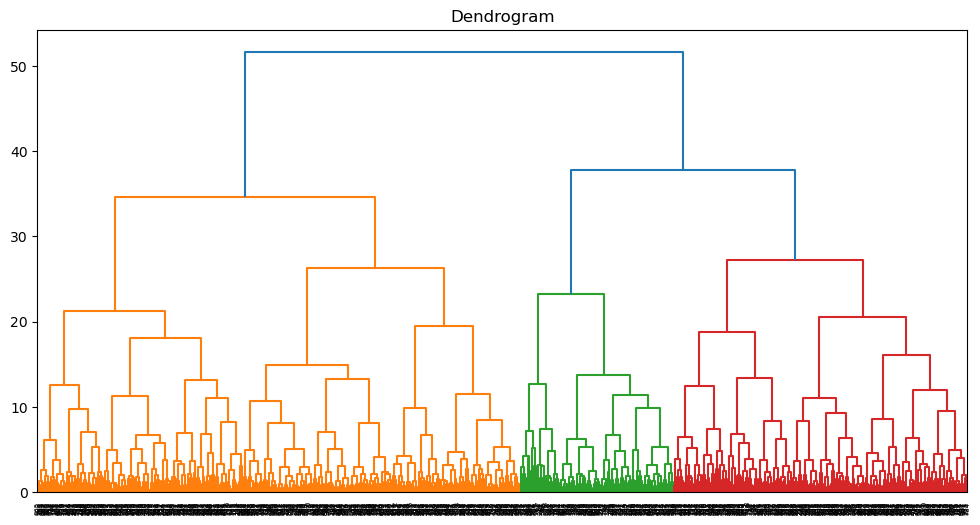

In [41]:
from scipy.cluster.hierarchy import linkage , dendrogram

linkage_matrix = linkage(scaled_df, method='ward')

plt.figure(figsize=(12,6))

dendrogram(linkage_matrix)

plt.title("Dendrogram")

plt.show()

# Now Doing PCA

In [42]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(scaled_df)

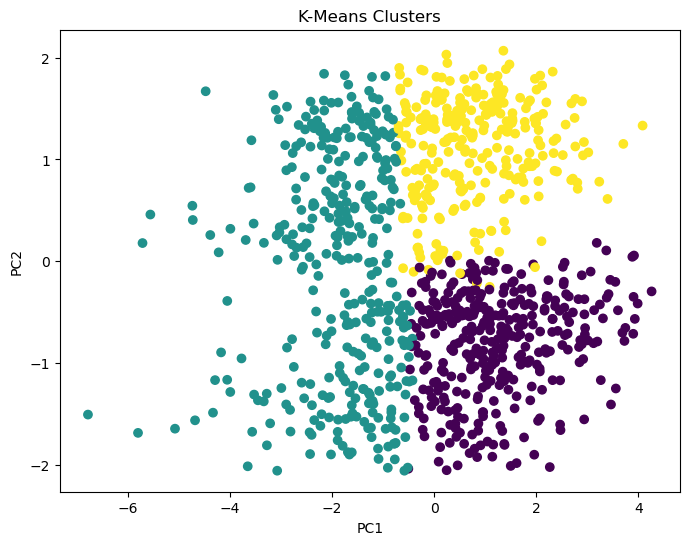

In [43]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df["KMeans_Cluster"],
    cmap='viridis'
)

plt.title("K-Means Clusters")

plt.xlabel("PC1")

plt.ylabel("PC2")

plt.show()

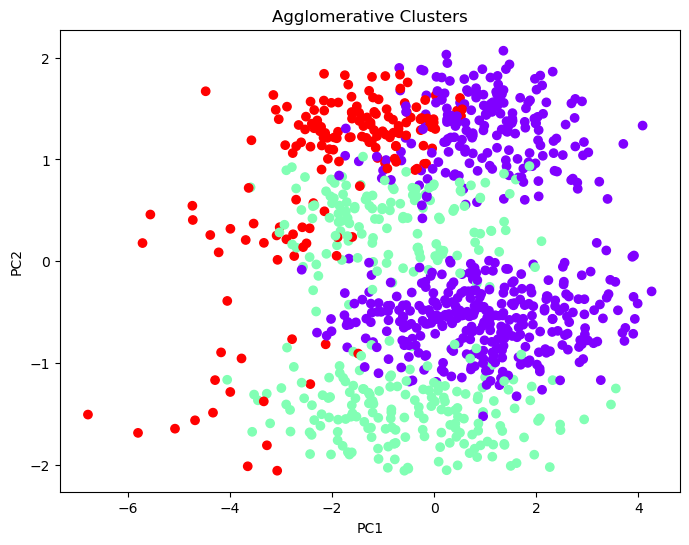

In [44]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df["Agg_Cluster"],
    cmap='rainbow'
)

plt.title("Agglomerative Clusters")

plt.xlabel("PC1")

plt.ylabel("PC2")

plt.show()

In [45]:
k_score = silhouette_score(scaled_df, df["KMeans_Cluster"])

a_score = silhouette_score(scaled_df, df["Agg_Cluster"])

print("KMeans :", k_score)

print("Agglomerative :", a_score)

KMeans : 0.1741060445115868
Agglomerative : 0.14932414956634324
